In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
import keras
import tensorflow as tf

In [ ]:
ipl = pd.read_csv('/content/drive/MyDrive/ipl_data.csv')
ipl.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


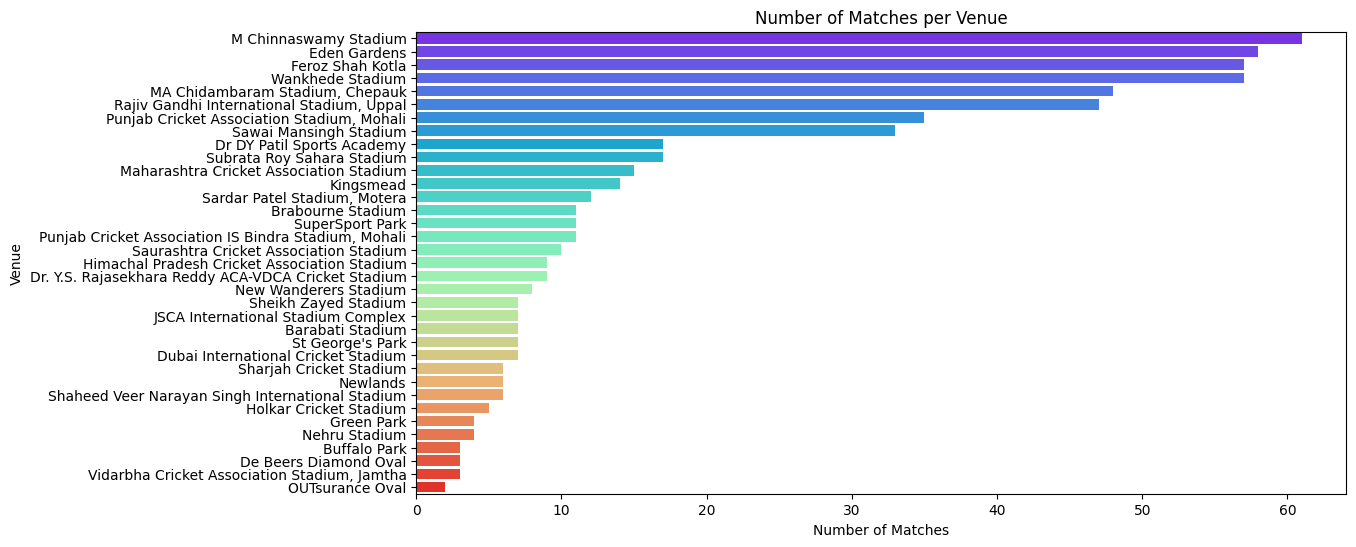

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
data = ipl.copy()
matches_per_venue = data[['mid', 'venue']].drop_duplicates()
matches_count = matches_per_venue['venue'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=matches_count.values, y=matches_count.index, hue=matches_count.index, palette="rainbow", legend=False)
plt.title('Number of Matches per Venue')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.show()

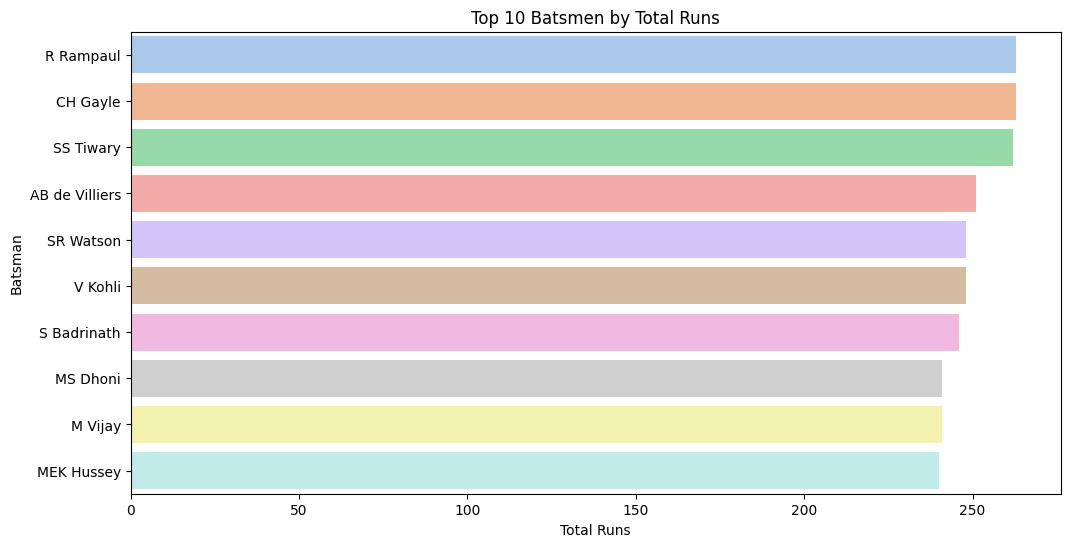

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
runs_by_batsman = data.groupby('batsman')['runs'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=runs_by_batsman.values, y=runs_by_batsman.index, hue=runs_by_batsman.index, palette="pastel", legend=False)
plt.title('Top 10 Batsmen by Total Runs')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.show()

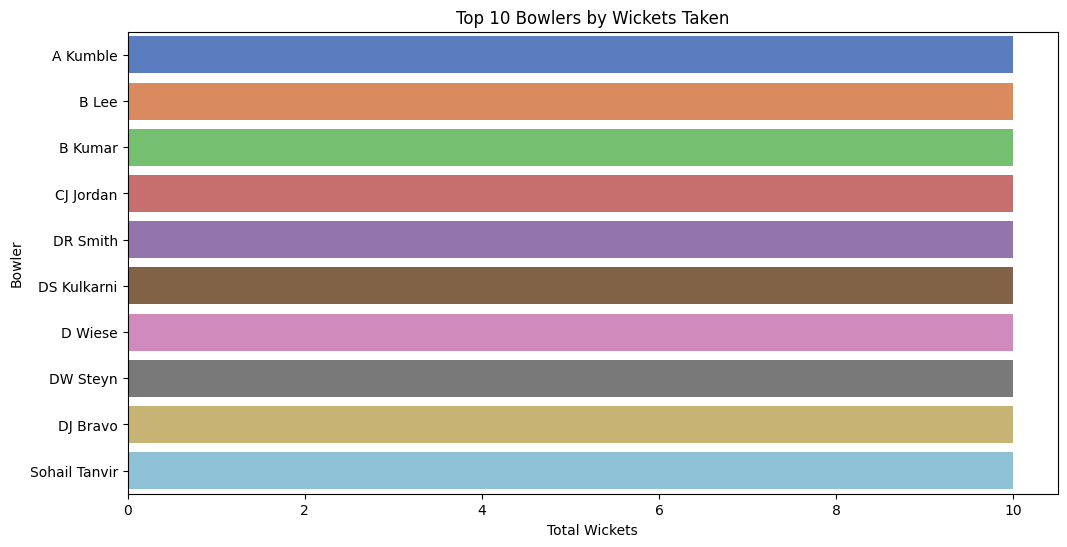

In [ ]:
wickets_by_bowler = data.groupby(
    'bowler')['wickets'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=wickets_by_bowler.values,
            y=wickets_by_bowler.index, palette="muted")
plt.title('Top 10 Bowlers by Wickets Taken')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['bat_team', 'bowl_team', 'venue', "batsman", "bowler"]

data_encoded = data.copy()

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data_encoded[col])
    label_encoders[col] = le

In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['bat_team', 'bowl_team', 'venue', "batsman", "bowler"]

data_encoded = data.copy()

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data_encoded[col])
    label_encoders[col] = le

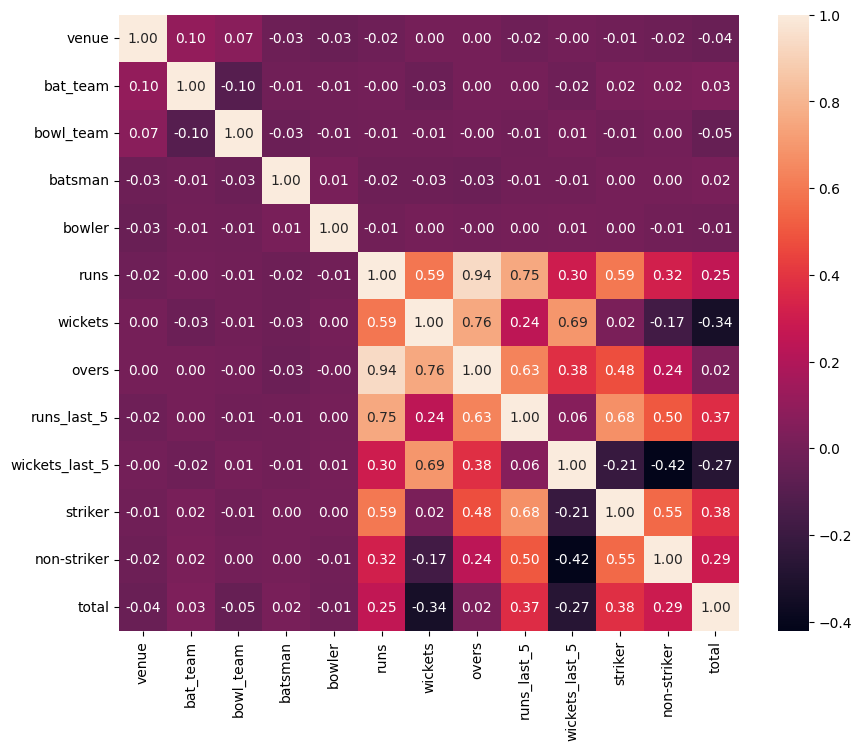

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

data_corr = data_encoded.drop(columns=["date", "mid"], axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    data_corr.corr(),
    annot=True,
    cmap="rocket",   # default-like colormap used in your image
    fmt=".2f"
)

plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
feature_cols = ['bat_team', 'bowl_team', 'venue', 'runs',
                'wickets', 'overs', 'striker', 'batsman', 'bowler']

X = data_encoded[feature_cols]
y = data_encoded['total']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import keras
import tensorflow as tf
model = keras.Sequential([
    keras.layers.Input( shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(216, activation='relu'),
    keras.layers.Dense(1, activation='linear')
])

huber_loss = tf.keras.losses.Huber(delta=1.0)  # You can adjust the 'delta' parameter as needed
model.compile(optimizer='adam', loss=huber_loss)

In [ ]:
model.fit(X_train_scaled, y_train, epochs=10, batch_size=64, validation_data=(X_test_scaled, y_test))

Epoch 1/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 50.7170 - val_loss: 14.8668
Epoch 2/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 15.1198 - val_loss: 14.4148
Epoch 3/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 14.6097 - val_loss: 14.2927
Epoch 4/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 14.5325 - val_loss: 14.1046
Epoch 5/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 14.4294 - val_loss: 13.9094
Epoch 6/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 14.2994 - val_loss: 13.8765
Epoch 7/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 14.3869 - val_loss: 13.8785
Epoch 8/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 14.1213 - val_loss: 13.8419
Epoch 9/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 14.2631 - val_loss: 13.7760
Epoch 10/10
832/832 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 14.1722 - val_loss: 13.8901


<Axes: >

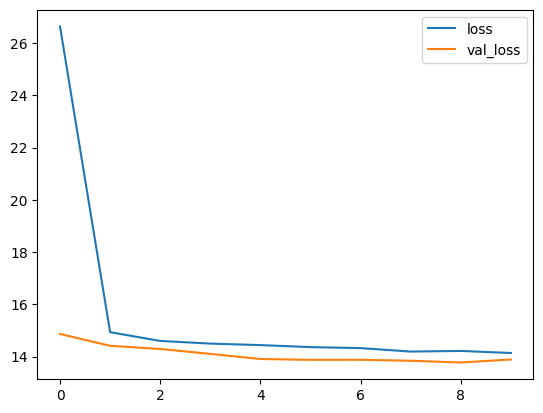

In [ ]:
model_losses = pd.DataFrame(model.history.history)
model_losses.plot()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
predictions = model.predict(X_test_scaled)

mean_absolute_error(y_test, predictions)

NameError: name 'model' is not defined

In [ ]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings("ignore")

# Re-define label_encoders here to ensure it's available
from sklearn.preprocessing import LabelEncoder
import pandas as pd # Import pandas for read_csv

# Ensure ipl is loaded if not already
if 'ipl' not in globals():
    try:
        ipl = pd.read_csv('/content/drive/MyDrive/ipl_data.csv')
        print("ipl data loaded successfully within the prediction widget cell.")
    except FileNotFoundError:
        print("Error: 'ipl_data.csv' not found. Please ensure the file is correctly placed.")
        # You might want to stop execution or handle this error more robustly
    except Exception as e:
        print(f"An unexpected error occurred while loading 'ipl_data.csv': {e}")
        # Handle other potential errors during file loading

# This part assumes 'data' is available, which it should be from cell 'p_vcebw6gKwb'
# If 'data' is not defined, we should re-create it.
if 'data' not in globals() and 'ipl' in globals(): # Ensure ipl is defined before trying to copy
    data = ipl.copy()
elif 'data' not in globals() and 'ipl' not in globals():
    print("Warning: 'ipl' DataFrame not available, cannot initialize 'data'. Some functionalities might fail.")

cat_cols = ['bat_team', 'bowl_team', 'venue', "batsman", "bowler"]

label_encoders = {}

# Ensure 'data' is available before trying to fit encoders
if 'data' in globals():
    for col in cat_cols:
        le = LabelEncoder()
        label_encoders[col] = le
        label_encoders[col].fit(data[col]) # Fit the encoder with data
else:
    print("Error: 'data' DataFrame is not available for fitting LabelEncoders. Please ensure 'ipl' is loaded.")

# ===================== WIDGETS =====================

# Ensure label_encoders is populated before creating widgets
if not label_encoders:
    print("Error: Label encoders not initialized. Cannot create widgets.")
    # You might want to exit or return here

venue = widgets.Dropdown(
    options=list(label_encoders['venue'].classes_),
    description='Select Venue:'
)
venue.style = {'description_width': 'initial'}

batting_team = widgets.Dropdown(
    options=list(label_encoders['bat_team'].classes_),
    description='Select Batting Team:'
)
batting_team.style = {'description_width': 'initial'}

bowling_team = widgets.Dropdown(
    options=list(label_encoders['bowl_team'].classes_),
    description='Select Bowling Team:'
)
bowling_team.style = {'description_width': 'initial'}

striker = widgets.Dropdown(
    options=list(label_encoders['batsman'].classes_),
    description='Select Striker:'
)
striker.style = {'description_width': 'initial'}

bowler = widgets.Dropdown(
    options=list(label_encoders['bowler'].classes_),
    description='Select Bowler:'
)
bowler.style = {'description_width': 'initial'}

wickets = widgets.IntText(
    value=3, description='Wickets:'
)
wickets.style = {'description_width': 'initial'}

overs = widgets.FloatText(
    value=7.0, description='Overs:'
)
overs.style = {'description_width': 'initial'}

striker_ind = widgets.IntText(
    value=1, description='Striker Indicator (0/1):'
)
striker_ind.style = {'description_width': 'initial'}

predict_button = widgets.Button(description="Predict Score")
output = widgets.Output()

# ===================== PREDICTION FUNCTION =====================

def predict_score(b):
    with output:
        clear_output()

        # Ensure label_encoders is populated
        if not label_encoders:
            print("Error: Label encoders not initialized. Cannot make prediction.")
            return

        encoded_venue = label_encoders['venue'].transform([venue.value])[0]
        encoded_batting_team = label_encoders['bat_team'].transform(
            [batting_team.value])[0]
        encoded_bowling_team = label_encoders['bowl_team'].transform(
            [bowling_team.value])[0]
        encoded_striker = label_encoders['batsman'].transform(
            [striker.value])[0]
        encoded_bowler = label_encoders['bowler'].transform(
            [bowler.value])[0]

        # Original feature_cols = ['bat_team', 'bowl_team', 'venue', 'runs', 'wickets', 'overs', 'striker', 'batsman', 'bowler']
        # The 'runs' feature is not available from widgets. Using 0 as a placeholder.
        # 'overs' in feature_cols refers to the current overs, not remaining_overs.
        input_features = [
            encoded_batting_team, # Index 0: bat_team
            encoded_bowling_team, # Index 1: bowl_team
            encoded_venue,        # Index 2: venue
            0,                    # Index 3: runs (Placeholder, not available from widgets)
            wickets.value,        # Index 4: wickets
            overs.value,          # Index 5: overs
            striker_ind.value,    # Index 6: striker (assuming striker_ind matches 'striker')
            encoded_striker,      # Index 7: batsman
            encoded_bowler        # Index 8: bowler
        ]

        input_array = np.array(input_features).reshape(1, -1)

        # Ensure scaler and model are defined
        if 'scaler' not in globals():
            print("Error: Scaler not found. Please ensure the model preprocessing steps are run.")
            return
        if 'model' not in globals():
            print("Error: Model not found. Please ensure the model training steps are run.")
            return

        input_array_scaled = scaler.transform(input_array)

        predicted_score = model.predict(input_array_scaled)

        print("Current Overs:", overs.value)
        print("Wickets:", wickets.value)
        print(f"Predicted Total Runs: {int(predicted_score[0])}")

# ===================== BUTTON EVENT =====================

predict_button.on_click(predict_score)

display(
    venue,
    batting_team,
    bowling_team,
    striker,
    bowler,
    wickets,
    overs,
    striker_ind,
    predict_button,
    output
)

ipl data loaded successfully within the prediction widget cell.


Dropdown(description='Select Venue:', options=('Barabati Stadium', 'Brabourne Stadium', 'Buffalo Park', 'De Be…

Dropdown(description='Select Batting Team:', options=('Chennai Super Kings', 'Deccan Chargers', 'Delhi Daredev…

Dropdown(description='Select Bowling Team:', options=('Chennai Super Kings', 'Deccan Chargers', 'Delhi Daredev…

Dropdown(description='Select Striker:', options=('A Ashish Reddy', 'A Chandila', 'A Chopra', 'A Choudhary', 'A…

...

IntText(value=3, description='Wickets:', style=DescriptionStyle(description_width='initial'))

FloatText(value=7.0, description='Overs:', style=DescriptionStyle(description_width='initial'))

IntText(value=1, description='Striker Indicator (0/1):', style=DescriptionStyle(description_width='initial'))

Button(description='Predict Score', style=ButtonStyle())

Output()